# TENG 手势信号预处理流程文档

## 项目概述

本项目使用 **TENG（摩擦纳米发电机）传感器** 采集手部手势信号。传感器贴合在手部，
当做出不同手势时，传感器因摩擦产生电压变化。通过分析这些电压波形，可以识别出不同的手势动作。

**数据规格：**
- **传感器通道**：共 8 通道采集，使用其中 3 个有效通道（CH1、CH3、CH5）
- **采样率**：1000 Hz（每秒 1000 个数据点）
- **手势类别**：10 种（1, 2, 3, 4, 5, go_the_way, ok, sc, stop, wave）
- **采集环境**：3 种（正常环境 base、风噪 wind_noise、紫外辐照 uv_radiation）

**核心挑战：** 每个 CSV 文件包含同一手势的 **多次重复动作**（5~20 次），需要自动切分为单个动作片段，
再进行信号清洗和特征提取，最终用于训练分类模型。

本 Notebook 完整展示预处理的每一步：原始信号 → 动作切分 → 信号清洗 → 特征提取 → 统计分析。

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess.io import load_raw_csv, GESTURE_NAMES
from src.preprocess.segmenter import SegParams, segment_file, analyze_single_channel, detect_joint_actions
from src.preprocess.cleaner import clean_segment, build_filters
from src.preprocess.features import calculate_9d_vector, FEATURE_NAMES

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FS = 1000
CH_NAMES = ['CH1', 'CH3', 'CH5']
CH_COLORS = ['#2196F3', '#4CAF50', '#FF9800']

---
## 1. 原始信号观察

### 为什么要先看原始信号？

在做任何处理之前，需要直观理解数据的基本特征：
- 信号的幅值范围和基线水平
- 动作信号与静息信号的对比
- 各通道之间的差异

### 数据格式

每个 CSV 文件有 8 列（无表头），我们使用第 0、2、4 列，分别对应传感器的 CH1、CH3、CH5 通道。
这三个通道分布在手部不同位置，不同手势会在不同通道上产生不同强度的信号。

下面加载一个示例文件 `stop-1.csv`（base 环境下的 "stop" 手势，包含约 20 次重复动作），
绘制三通道的时域波形。

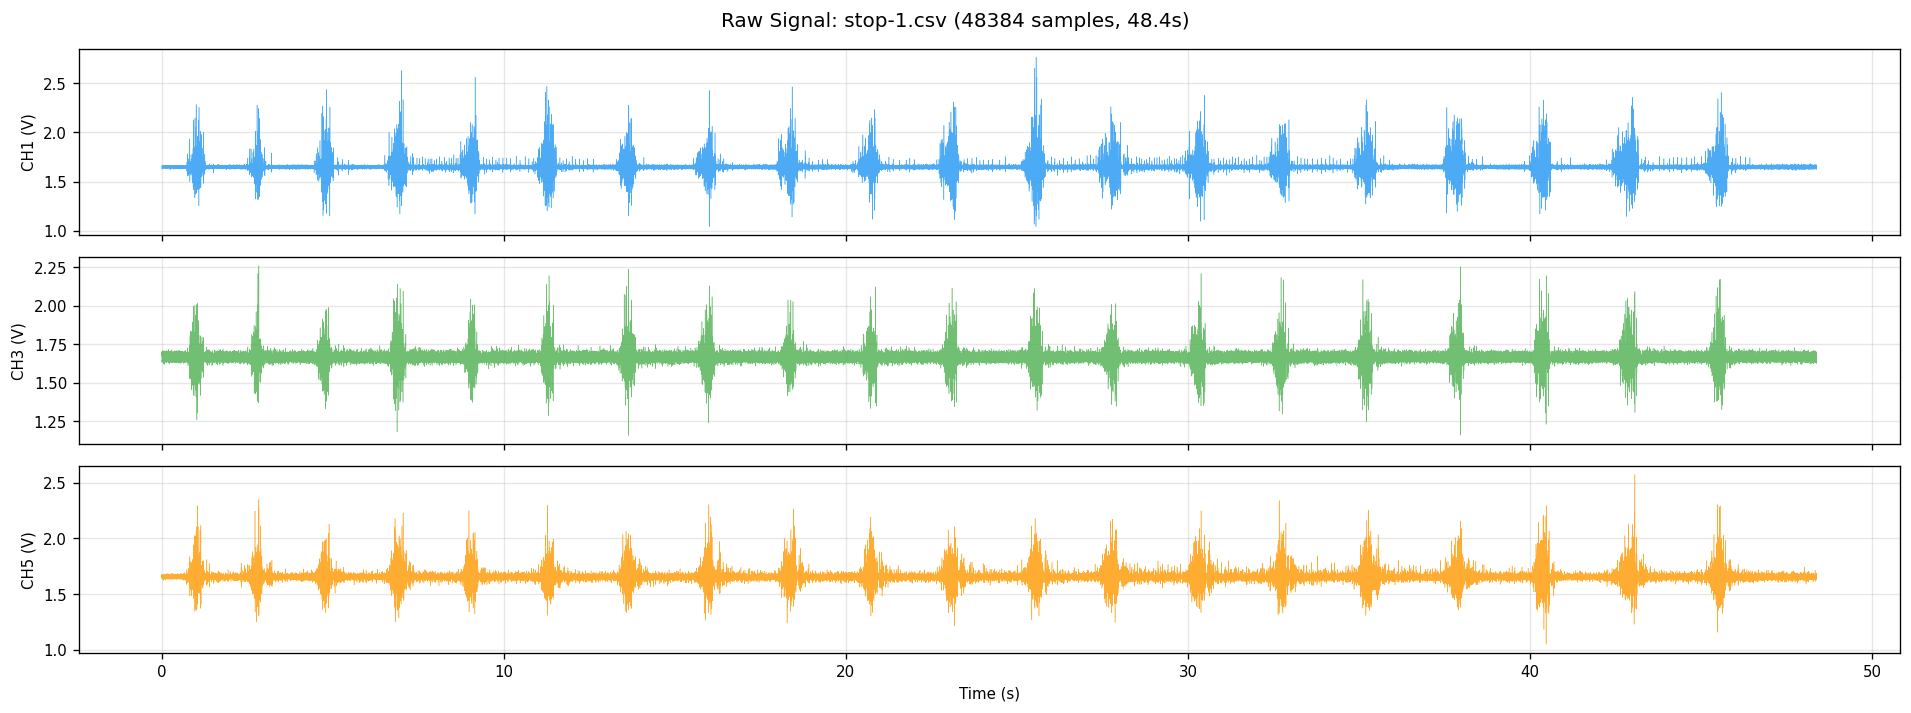

File: stop-1.csv
Shape: (48384, 3) (samples x channels)
Duration: 48.38 s
CH1: mean=1.6510V, std=0.073390V, range=[1.0425, 2.7652]
CH3: mean=1.6618V, std=0.051648V, range=[1.1569, 2.2607]
CH5: mean=1.6546V, std=0.060878V, range=[1.0529, 2.5732]


In [2]:
sample_file = RAW_DIR / 'base' / 'stop-1.csv'
signal = load_raw_csv(sample_file)
time_s = np.arange(len(signal)) / FS

fig, axes = plt.subplots(3, 1, figsize=(16, 6), sharex=True)
for i, (ax, name, color) in enumerate(zip(axes, CH_NAMES, CH_COLORS)):
    ax.plot(time_s, signal[:, i], color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(f'{name} (V)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw Signal: {sample_file.name} ({len(signal)} samples, {time_s[-1]:.1f}s)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'File: {sample_file.name}')
print(f'Shape: {signal.shape} (samples x channels)')
print(f'Duration: {time_s[-1]:.2f} s')
for i, name in enumerate(CH_NAMES):
    col = signal[:, i]
    print(f'{name}: mean={col.mean():.4f}V, std={col.std():.6f}V, range=[{col.min():.4f}, {col.max():.4f}]')

### 如何读这张图

- **X 轴**：时间（秒），整个文件约 48 秒，包含约 20 次 stop 手势
- **Y 轴**：原始电压值（V），基线约在 1.65V 附近
- **周期性的尖峰**：每个尖峰对应一次手势动作，间隔约 2 秒
- **三通道差异**：不同通道的响应幅度和波形形状不同，这正是区分手势的关键信息
- **静息段**：两次动作之间的平坦区域，信号接近基线

可以看到，原始信号中动作信号的幅值变化相对较小（通常只有几十 mV），
需要通过滤波去噪来增强信噪比。

---
## 2. 不同环境下的信号对比

三种采集环境会影响信号质量：

| 环境 | 说明 | 影响 |
|------|------|------|
| **base** | 正常实验室环境 | 基准信号，信噪比最高 |
| **wind_noise** | 60-85 dB 风噪 | 引入低频机械振动噪声 |
| **uv_radiation** | 紫外辐照 40mm 30min | 可能改变传感器材料特性 |

对比同一手势在不同环境下的信号，可以直观感受噪声的影响。

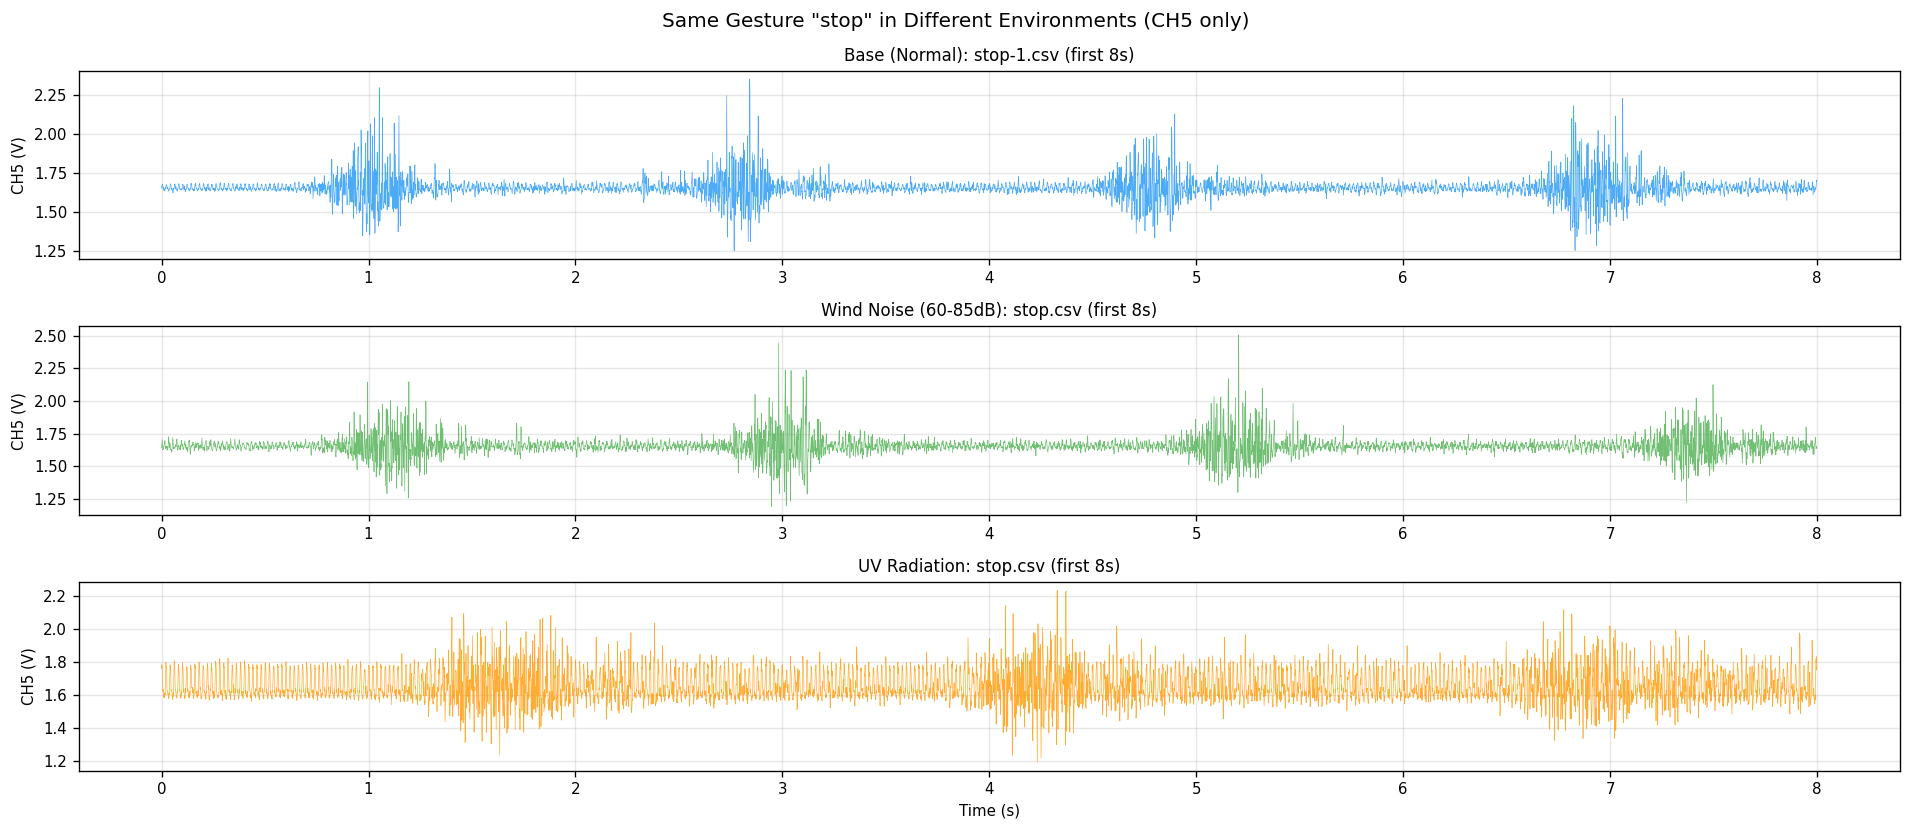

In [3]:
gesture = 'stop'
envs = ['base', 'wind_noise', 'uv_radiation']
env_labels = ['Base (Normal)', 'Wind Noise (60-85dB)', 'UV Radiation']
env_colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=False)

for ax, env, label, color in zip(axes, envs, env_labels, env_colors):
    if env == 'base':
        fname = f'{gesture}-1.csv'
    else:
        fname = f'{gesture}.csv'
    
    fpath = RAW_DIR / env / fname
    if fpath.exists():
        sig = load_raw_csv(fpath)
        t = np.arange(len(sig)) / FS
        # Only show CH5 (strongest response) for clarity
        ax.plot(t[:8000], sig[:8000, 2], color=color, linewidth=0.4, alpha=0.8)
        ax.set_ylabel('CH5 (V)')
        ax.set_title(f'{label}: {fname} (first 8s)', fontsize=10)
        ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Same Gesture "{gesture}" in Different Environments (CH5 only)', fontsize=12)
plt.tight_layout()
plt.show()

### 如何读这张图

三幅图展示同一手势（stop）在三种环境下前 8 秒的 CH5 信号：

- **Base**：信号清晰，静息段平稳，动作峰值明显
- **Wind Noise**：基线有明显的低频波动（风噪引起的机械振动），但动作信号仍可辨识
- **UV Radiation**：基线特性可能略有变化（材料特性改变），但总体波形结构相似

这说明 TENG 传感器在不同干扰下仍能产生可识别的手势信号，验证其鲁棒性。

---
## 3. 动作切分

### 为什么需要切分？

每个 CSV 文件包含同一手势的 **多次重复动作**（5~20 次连续做）。
要训练分类模型，需要把每次动作单独切出来，形成独立的训练样本。

### 切分算法原理

切分基于 **滑动 RMS（均方根）包络** 检测激活段：

1. **去中心化**：对每个通道，减去中位数，消除直流偏置
2. **滑动 RMS**：用 200ms 窗口计算 RMS 包络，将高频振荡信号转化为平滑的能量曲线
3. **基线估计**：取 RMS 最低 20% 的值的均值和标准差，代表静息状态的噪声水平
4. **激活阈值**：`threshold = baseline_mean + 3 * baseline_std`（超过基线 3 倍标准差即视为激活）
5. **激活段检测**：RMS 超过阈值的连续区域，最短 100ms，相邻激活段间隔 <200ms 则合并
6. **跨通道联合检测**：至少 2 个通道同时激活才认定为一次有效手势动作
7. **纯净度自检**：若任一通道在动作窗口内出现多次独立激活（断裂），丢弃该段

下面逐步可视化这个过程。

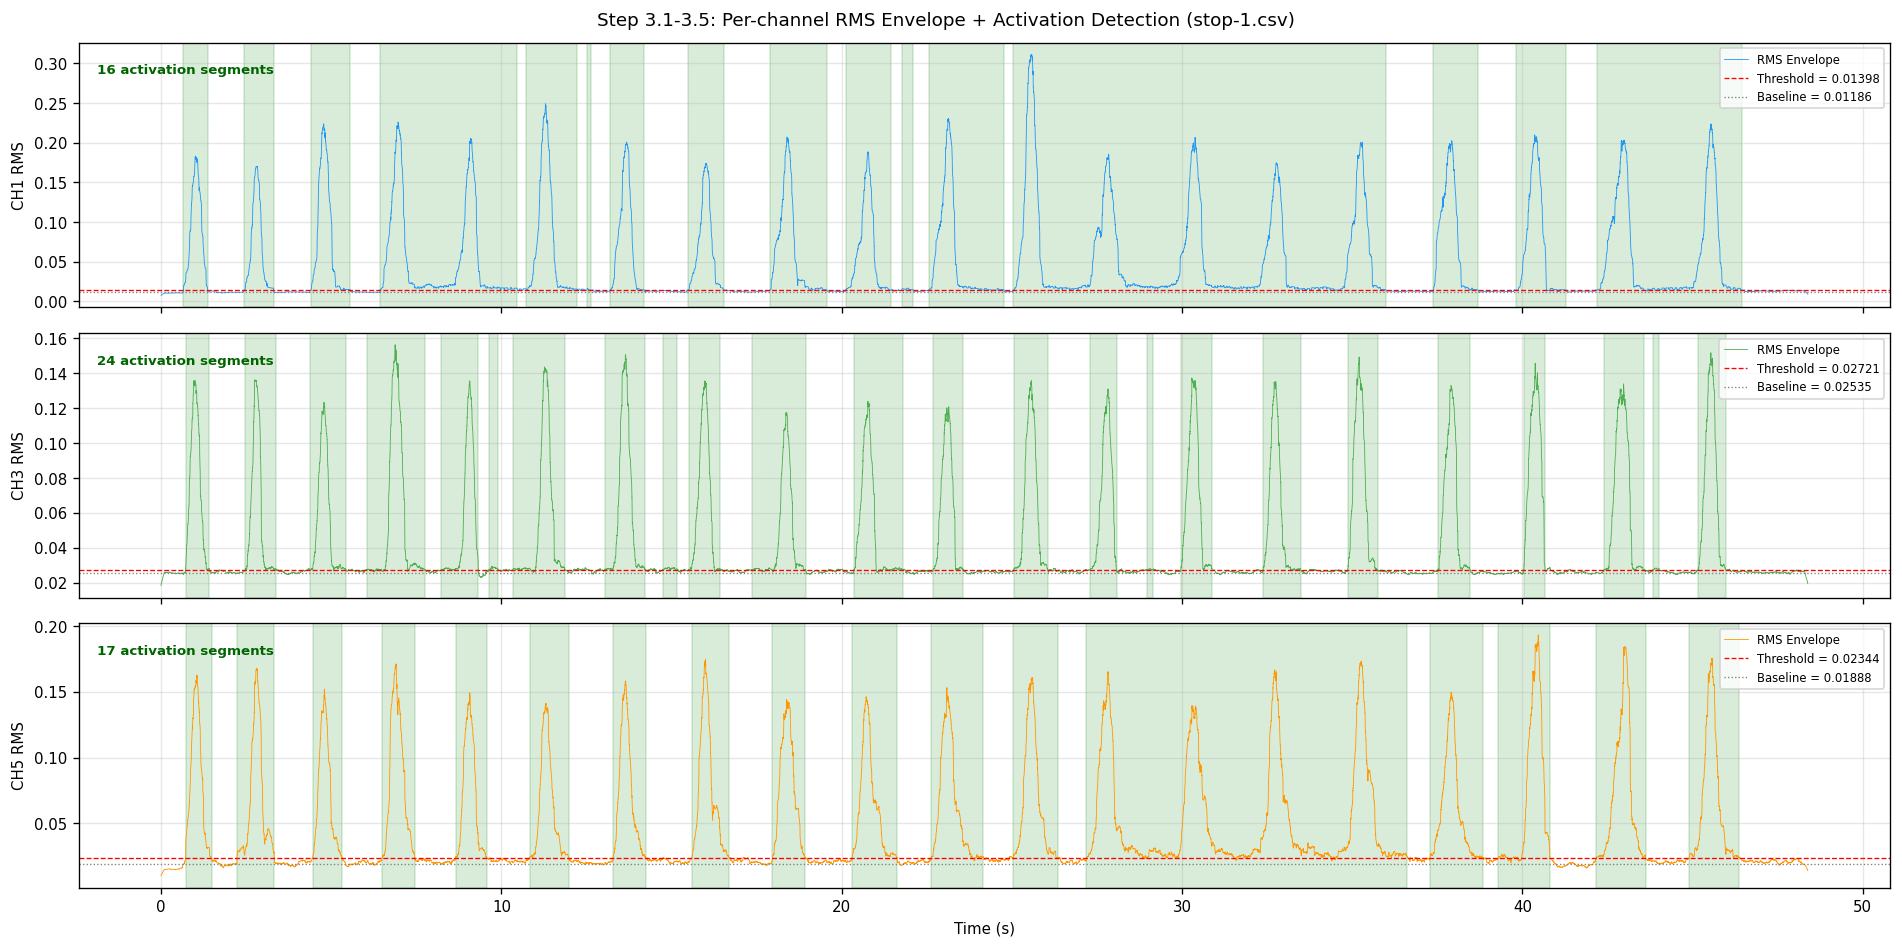

In [4]:
params = SegParams(fs=FS)

# Per-channel analysis
ch_analyses = [analyze_single_channel(signal[:, ch], params) for ch in range(3)]

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
for i, (ax, name, color, analysis) in enumerate(zip(axes, CH_NAMES, CH_COLORS, ch_analyses)):
    ax.plot(time_s, analysis['rms_env'], color=color, linewidth=0.5, label='RMS Envelope')
    ax.axhline(analysis['threshold'], color='red', linestyle='--', linewidth=0.8,
               label=f'Threshold = {analysis["threshold"]:.5f}')
    ax.axhline(analysis['baseline_mean'], color='gray', linestyle=':', linewidth=0.8,
               label=f'Baseline = {analysis["baseline_mean"]:.5f}')
    for a, b in analysis['active_segments']:
        ax.axvspan(a / FS, b / FS, alpha=0.15, color='green')
    ax.set_ylabel(f'{name} RMS')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)
    n_segs = len(analysis['active_segments'])
    ax.text(0.01, 0.92, f'{n_segs} activation segments', transform=ax.transAxes,
            fontsize=8, va='top', color='darkgreen', fontweight='bold')

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Step 3.1-3.5: Per-channel RMS Envelope + Activation Detection ({sample_file.name})', fontsize=11)
plt.tight_layout()
plt.show()

### 如何读这张图

- **蓝/绿/橙色曲线**：各通道的滑动 RMS 包络，反映信号瞬时能量
- **红色虚线**：激活阈值（baseline_mean + 3*baseline_std），超过此线即判定为激活
- **灰色点线**：基线均值，代表静息噪声水平
- **绿色色块**：检测到的激活段（每个色块 = 一次手势动作）
- **左上角数字**：该通道检测到的激活段数量

可以看到：
- CH5（橙色）的响应最强，RMS 峰值最高
- 不同通道检测到的激活段数量可能不同（因为某些动作在某通道上响应较弱）
- 这就是为什么需要跨通道联合检测——确保至少 2 个通道同时激活才算有效动作

Joint actions (cross-channel, purity-checked): 15


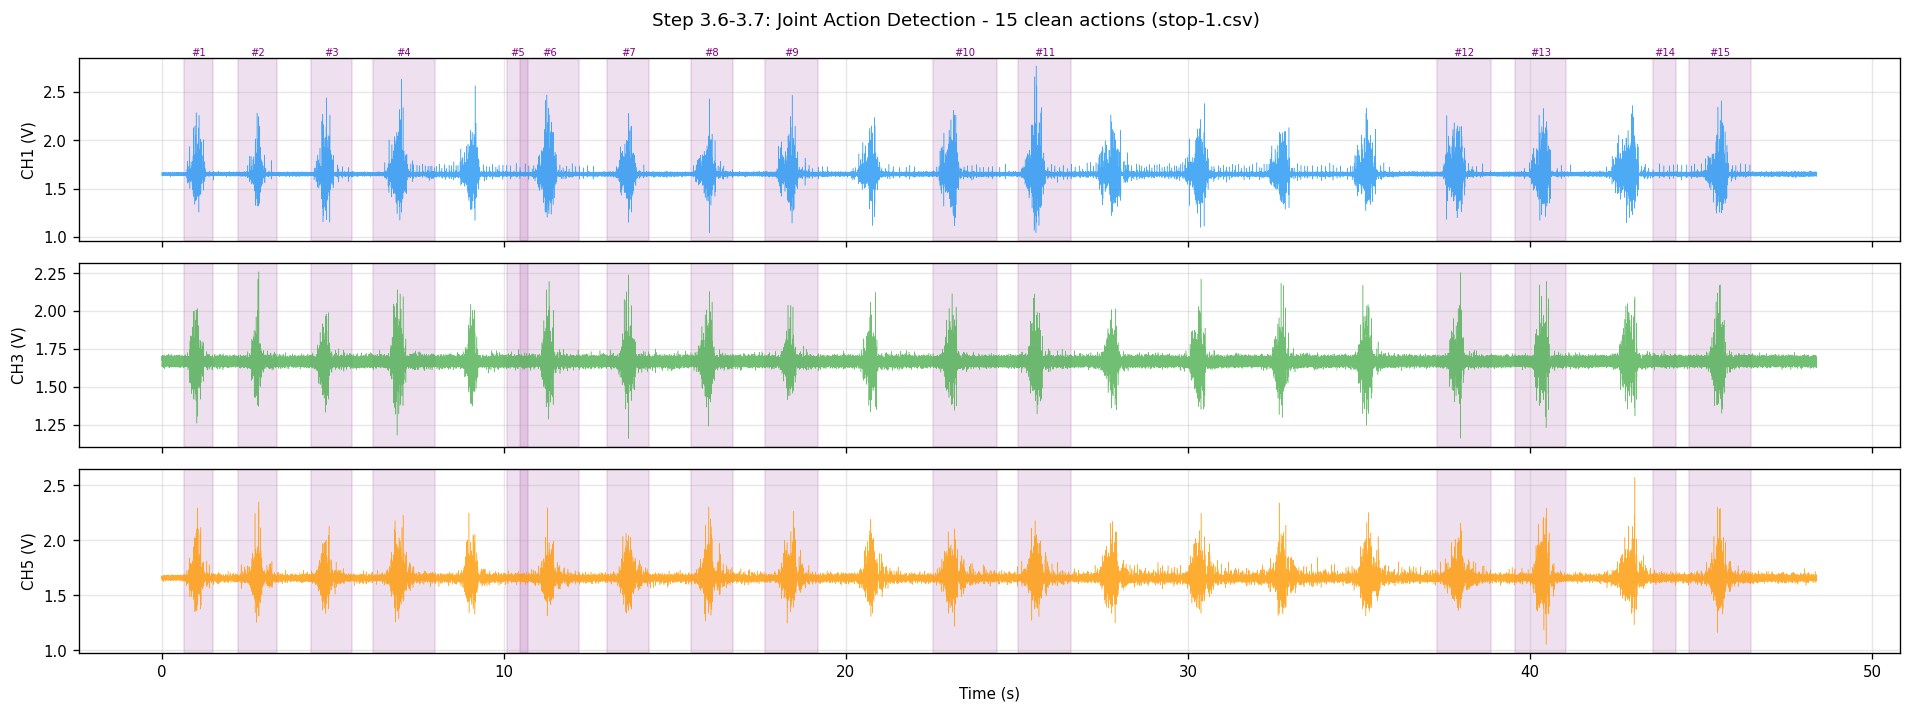

In [5]:
# Joint action detection
joint_actions = detect_joint_actions(signal, params)
print(f'Joint actions (cross-channel, purity-checked): {len(joint_actions)}')

fig, axes = plt.subplots(3, 1, figsize=(16, 6), sharex=True)
for i, (ax, name, color) in enumerate(zip(axes, CH_NAMES, CH_COLORS)):
    ax.plot(time_s, signal[:, i], color=color, linewidth=0.3, alpha=0.8)
    for idx, (a, b) in enumerate(joint_actions):
        ax.axvspan(a / FS, b / FS, alpha=0.12, color='purple')
        if i == 0:
            mid = (a + b) / 2 / FS
            ylim = ax.get_ylim()
            ax.text(mid, ylim[1], f'#{idx+1}', ha='center', fontsize=6, color='purple', va='bottom')
    ax.set_ylabel(f'{name} (V)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Step 3.6-3.7: Joint Action Detection - {len(joint_actions)} clean actions ({sample_file.name})', fontsize=11)
plt.tight_layout()
plt.show()

### 如何读这张图

- **紫色色块**：最终确定的联合动作段，每个色块是一个通过纯净度自检的有效手势
- **编号 #1, #2, ...**：动作的顺序编号
- 原始信号中可能有 20 多次动作，但经过纯净度自检后保留的是信号质量最好的单次干净动作
- 被丢弃的动作通常是：信号断裂、多次发力叠加、或只有单通道响应的不完整动作

每个紫色色块将被切出，形成一个独立的训练样本。

---
## 4. 信号清洗

### 为什么需要清洗？

切出的原始动作片段仍包含多种噪声：
- **直流偏置**：传感器基线电压（~1.65V），对波形分析无意义
- **工频干扰**：50 Hz 交流电磁干扰（实验室环境常见）
- **带外噪声**：低于 20Hz 的基线漂移和高于 450Hz 的高频噪声
- **底噪**：传感器本身的白噪声

### 清洗流程（每个通道独立处理）

| 步骤 | 方法 | 目的 |
|------|------|------|
| 1. 去直流 | 减去均值 | 消除基线偏置，信号以零为中心 |
| 2. 带通滤波 | 4阶 Butterworth 20-450Hz | 只保留手势信号的有效频率范围 |
| 3. 陷波滤波 | IIR Notch 50Hz, Q=30 | 精确去除 50Hz 工频干扰 |
| 4. 谱减法 | STFT → 噪声估计 → 功率谱相减 → ISTFT | 自适应去除各频段的底噪 |
| 5. 边界裁切 | 首尾 500ms 内找包络最小值点 | 去除切分边界处的过渡伪迹 |

下面对一个切出的片段展示清洗前后的效果。

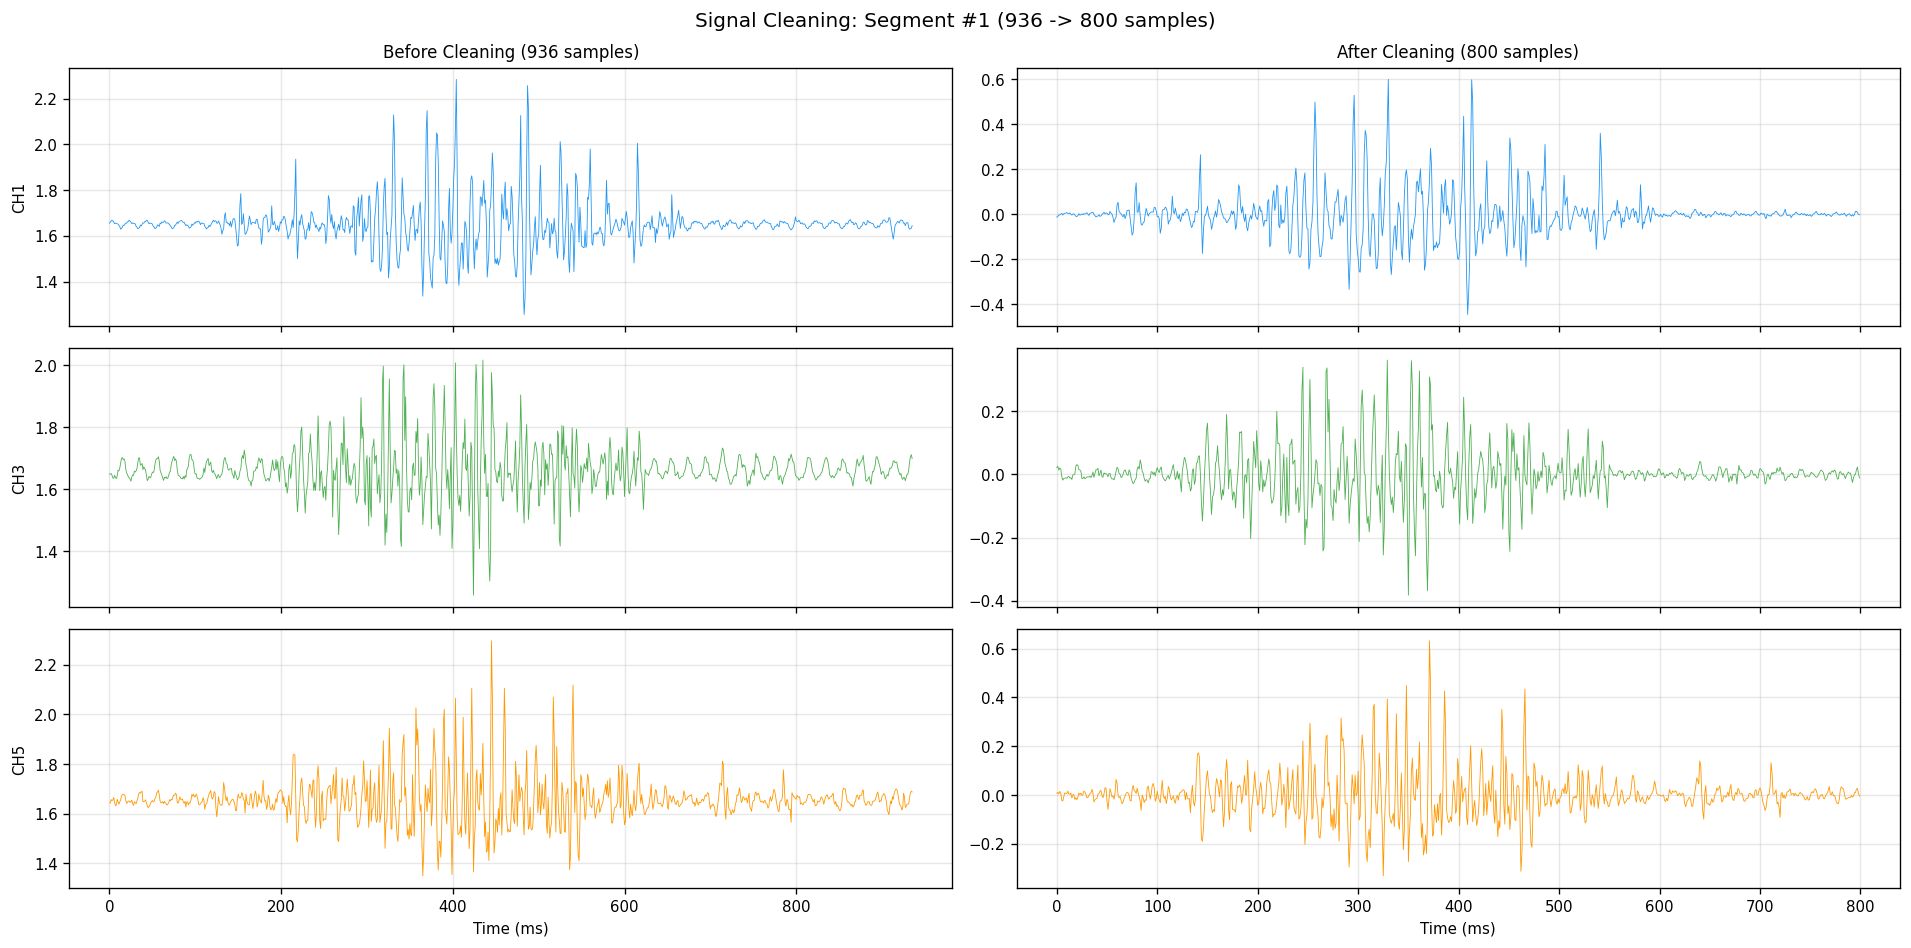

In [6]:
segments = segment_file(signal, params)
filters = build_filters(FS)

if segments:
    raw_seg = segments[0]
    cleaned_seg = clean_segment(raw_seg, fs=FS, filters=filters)
    t_raw = np.arange(len(raw_seg)) / FS * 1000
    t_clean = np.arange(len(cleaned_seg)) / FS * 1000

    fig, axes = plt.subplots(3, 2, figsize=(16, 8), sharex='col')

    for i, (name, color) in enumerate(zip(CH_NAMES, CH_COLORS)):
        # Before
        axes[i, 0].plot(t_raw, raw_seg[:, i], color=color, linewidth=0.5)
        axes[i, 0].set_ylabel(f'{name}')
        axes[i, 0].grid(True, alpha=0.3)
        if i == 0:
            axes[i, 0].set_title(f'Before Cleaning ({raw_seg.shape[0]} samples)', fontsize=10)

        # After
        axes[i, 1].plot(t_clean, cleaned_seg[:, i], color=color, linewidth=0.5)
        axes[i, 1].grid(True, alpha=0.3)
        if i == 0:
            axes[i, 1].set_title(f'After Cleaning ({cleaned_seg.shape[0]} samples)', fontsize=10)

    axes[-1, 0].set_xlabel('Time (ms)')
    axes[-1, 1].set_xlabel('Time (ms)')
    fig.suptitle(f'Signal Cleaning: Segment #1 ({raw_seg.shape[0]} -> {cleaned_seg.shape[0]} samples)', fontsize=12)
    plt.tight_layout()
    plt.show()

### 如何读这张图

- **左列（Before）**：切出的原始片段，信号以原始电压值为单位，包含直流偏置
- **右列（After）**：清洗后的片段，信号以零为中心，高频/低频噪声已去除

对比观察：
- 清洗后信号更干净，基线更平稳（去除了低频漂移）
- 动作信号的波形结构保留完好（有效频段 20-450Hz 未被破坏）
- 样本数可能减少（边界裁切去除了首尾过渡段）

### 频域对比

下面通过 FFT 频谱对比清洗效果，特别关注 50Hz 工频干扰的去除。

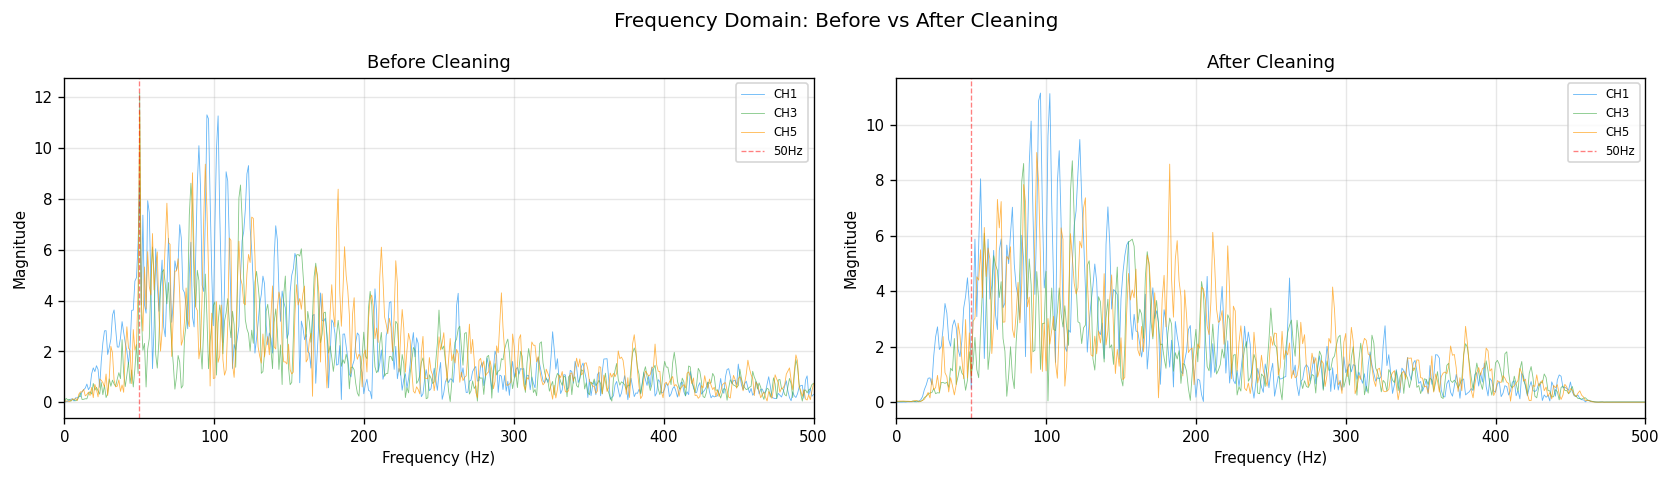

In [7]:
if segments:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for ch in range(3):
        # Before
        fft_raw = np.abs(np.fft.rfft(raw_seg[:, ch] - np.mean(raw_seg[:, ch])))
        freq_raw = np.fft.rfftfreq(len(raw_seg[:, ch]), 1/FS)
        axes[0].plot(freq_raw[:500], fft_raw[:500], color=CH_COLORS[ch],
                     linewidth=0.5, alpha=0.7, label=CH_NAMES[ch])
        
        # After
        fft_clean = np.abs(np.fft.rfft(cleaned_seg[:, ch]))
        freq_clean = np.fft.rfftfreq(len(cleaned_seg[:, ch]), 1/FS)
        axes[1].plot(freq_clean[:500], fft_clean[:500], color=CH_COLORS[ch],
                     linewidth=0.5, alpha=0.7, label=CH_NAMES[ch])
    
    for ax, title in zip(axes, ['Before Cleaning', 'After Cleaning']):
        ax.axvline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='50Hz')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 500)
    
    fig.suptitle('Frequency Domain: Before vs After Cleaning', fontsize=12)
    plt.tight_layout()
    plt.show()

### 如何读这张图

- **X 轴**：频率（Hz），范围 0-500Hz
- **Y 轴**：FFT 幅值（能量大小）
- **红色虚线**：50Hz 位置（工频干扰频率）

对比观察：
- **Before**：可能在 50Hz 处有一个明显的尖峰（工频干扰）
- **After**：50Hz 尖峰被陷波滤波器精确去除
- 20Hz 以下和 450Hz 以上的频段能量被带通滤波器抑制
- 整体噪声底部被谱减法进一步压低

---
## 5. 9D 特征提取

### 为什么用 9 维特征？

深度学习模型可以直接处理原始时域信号，但本项目数据量有限（约 500 个样本），
使用手工设计的物理特征更稳定、可解释性更好。

### 9 维特征向量

对每个清洗后的动作片段（3 通道），提取 3 类共 9 维特征：

| 特征 | 公式 | 物理含义 | 维度 |
|------|------|----------|------|
| **MAV**（平均绝对值） | `mean(abs(x))` | 信号的平均能量强度 | 3（每通道） |
| **WL**（波形长度） | `sum(abs(diff(x))) / duration` | 信号的复杂度/变化速率 | 3 |
| **Ratio**（能量比） | `RMS_ch / sum(RMS_all)` | 各通道的能量占比 | 3 |

- **MAV** 反映动作的力度大小
- **WL** 反映动作的速度和复杂程度
- **Ratio** 反映动作在空间上的能量分布（哪个通道响应最强）

不同手势的空间分布不同，因此 Ratio 特征对分类尤其重要。

In [8]:
all_feat = pd.read_csv(PROCESSED_DIR / 'features' / 'all_features.csv')
print(f'Total samples: {len(all_feat)}')
print(f'\nSamples per environment:')
print(all_feat['env'].value_counts().to_string())
print(f'\nSamples per gesture:')
print(all_feat['gesture_name'].value_counts().sort_index().to_string())

Total samples: 493

Samples per environment:
env
base            245
wind_noise      179
uv_radiation     69

Samples per gesture:
gesture_name
1             59
2             46
3             45
4             57
5             50
go_the_way    47
ok            50
sc            44
stop          52
wave          43


/var/folders/9l/34nn919x54d_sb8xzkdcmvlm0000gn/T/ipykernel_35730/19343506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_feat, x='gesture_name', y=feat, ax=ax,
/var/folders/9l/34nn919x54d_sb8xzkdcmvlm0000gn/T/ipykernel_35730/19343506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_feat, x='gesture_name', y=feat, ax=ax,
/var/folders/9l/34nn919x54d_sb8xzkdcmvlm0000gn/T/ipykernel_35730/19343506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_feat, x='gesture_name', y=feat, ax=ax,
/var/folders/9l/34nn919x5

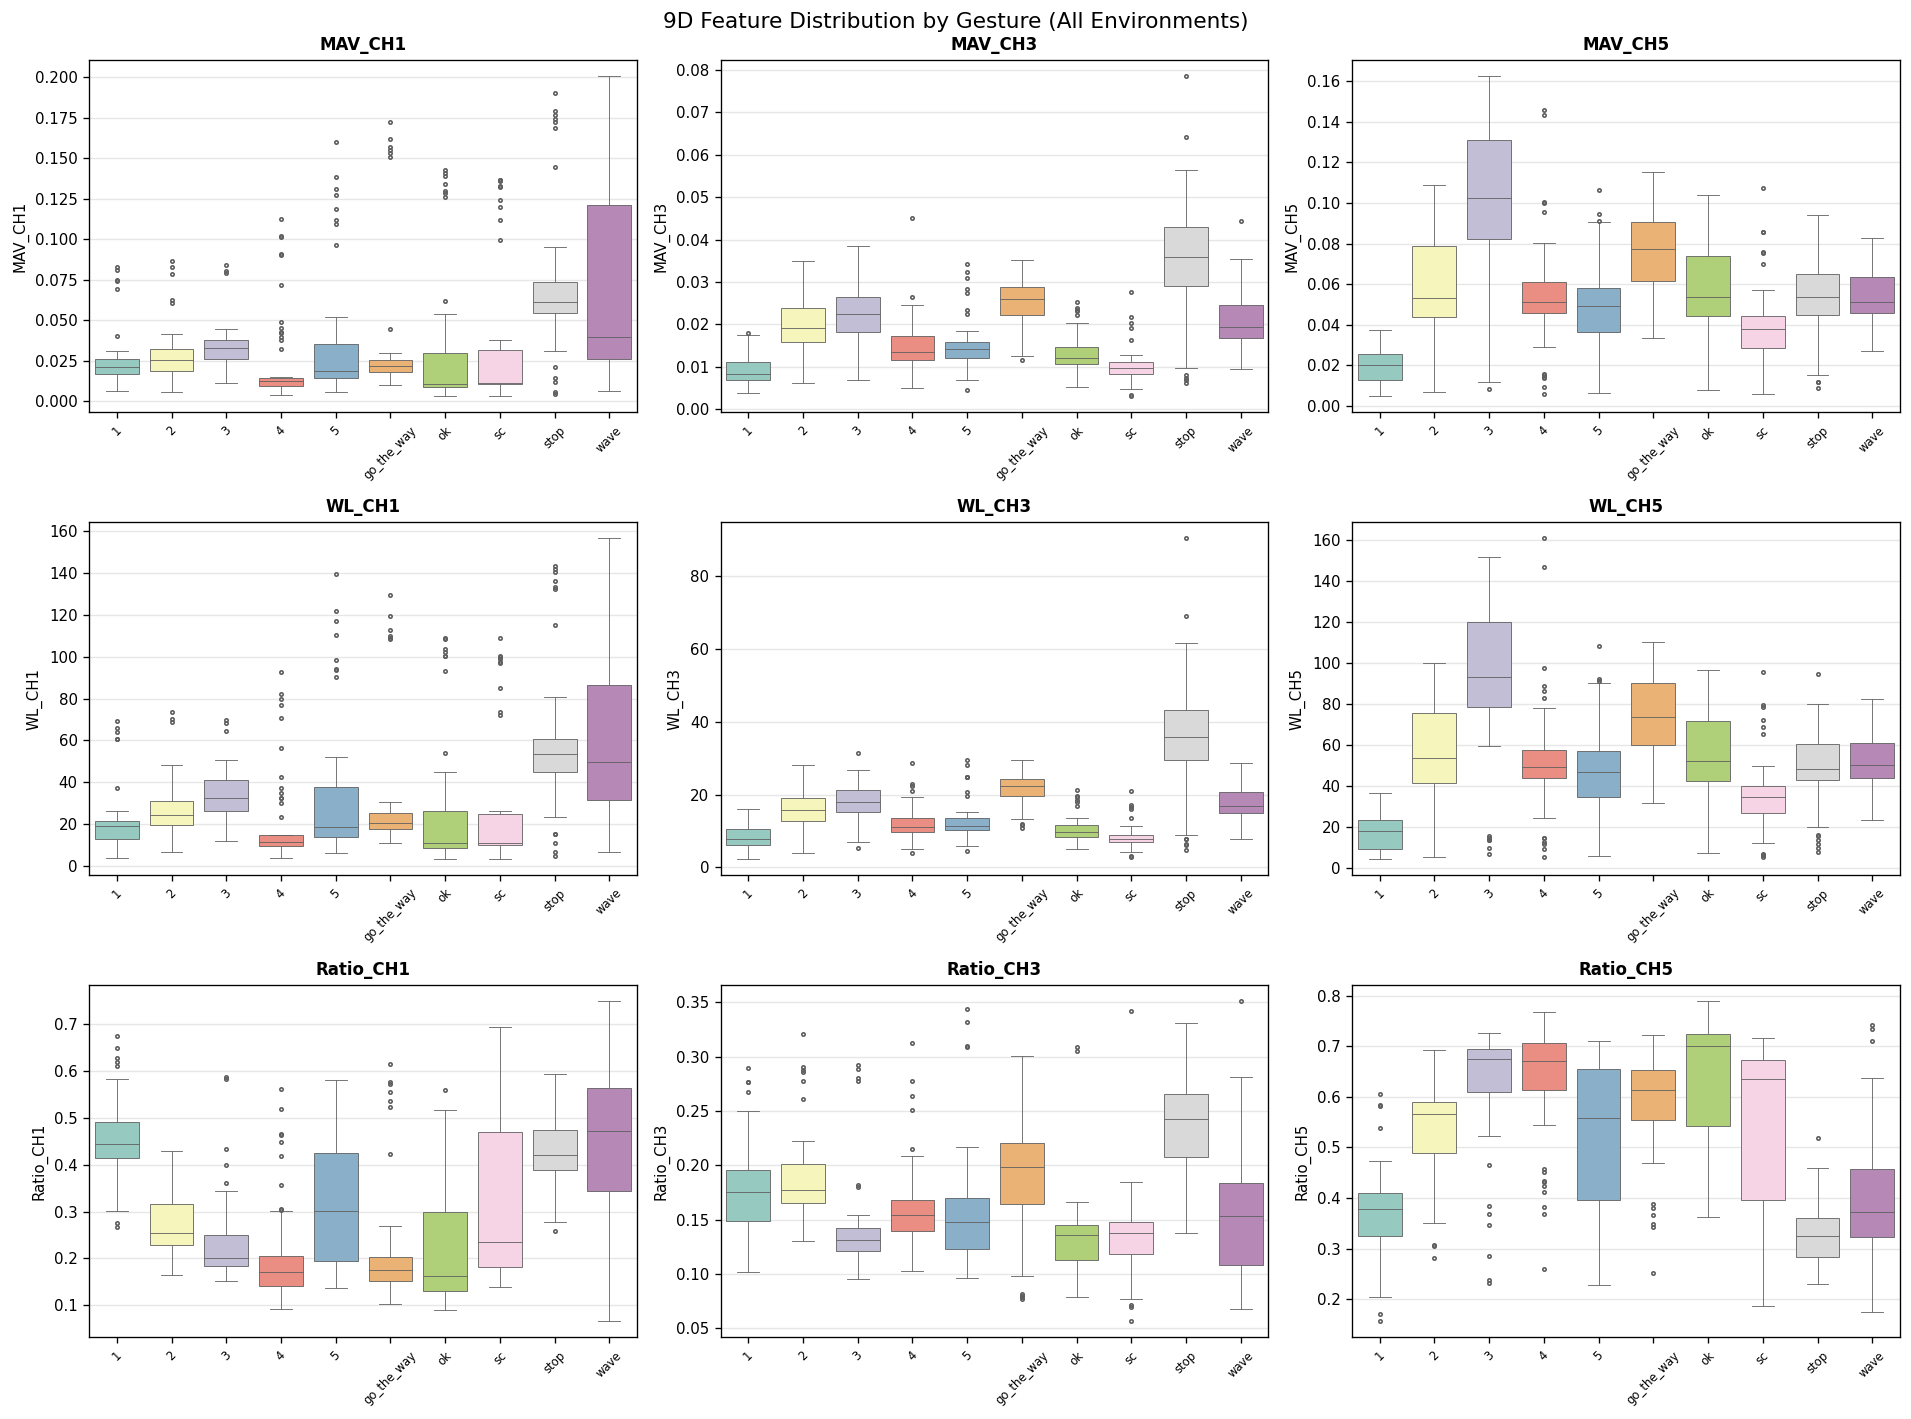

In [9]:
# Boxplot: feature distribution by gesture
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for idx, (ax, feat) in enumerate(zip(axes.flat, FEATURE_NAMES)):
    sns.boxplot(data=all_feat, x='gesture_name', y=feat, ax=ax,
                palette='Set3', linewidth=0.5, fliersize=2)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('9D Feature Distribution by Gesture (All Environments)', fontsize=13)
plt.tight_layout()
plt.show()

### 如何读这张图

9 个子图分别展示 9 个特征维度的箱线图，X 轴是 10 种手势，Y 轴是特征值。

**箱线图结构：**
- 箱体：25%-75% 分位数（中间 50% 数据的范围）
- 箱内横线：中位数
- 须线：延伸到 1.5 倍四分位距
- 圆点：离群值

**关注点：**
- **Ratio 特征**（最后一行）：不同手势的通道能量占比有明显差异，说明空间分布特征对分类很有用
- **MAV 特征**（第一行）：不同手势的力度有差异，但部分手势重叠较多
- **WL 特征**（第二行）：反映动作复杂度，某些手势（如 wave）的 WL 可能偏高

如果某个特征在不同手势之间箱体不重叠，说明该特征对区分这些手势很有效。

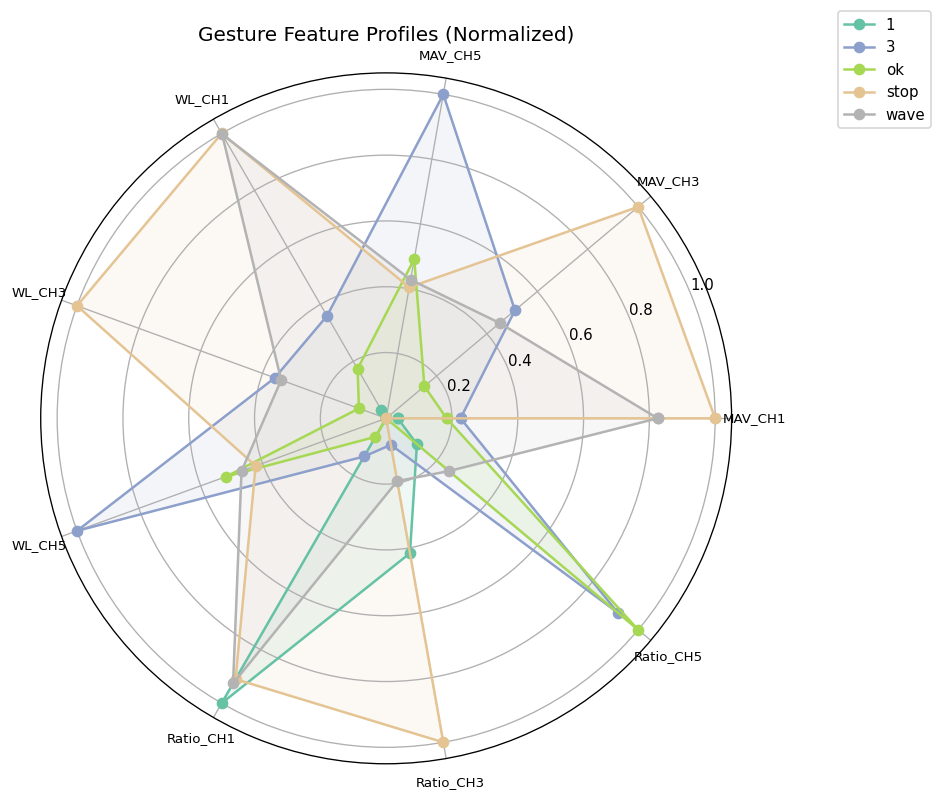

In [10]:
# Radar chart: compare gesture feature profiles
selected_gestures = ['1', '3', 'ok', 'stop', 'wave']
gesture_means = all_feat.groupby('gesture_name')[FEATURE_NAMES].mean()

feat_min = gesture_means.min()
feat_max = gesture_means.max()
feat_range = feat_max - feat_min
feat_range[feat_range == 0] = 1
gesture_normed = (gesture_means - feat_min) / feat_range

angles = np.linspace(0, 2 * np.pi, len(FEATURE_NAMES), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = plt.cm.Set2(np.linspace(0, 1, len(selected_gestures)))

for gesture, color in zip(selected_gestures, radar_colors):
    if gesture in gesture_normed.index:
        values = gesture_normed.loc[gesture].values.tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=1.5, label=gesture, color=color)
        ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURE_NAMES, fontsize=8)
ax.set_title('Gesture Feature Profiles (Normalized)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

### 如何读这张雷达图

- 每条折线代表一种手势在 9 个特征维度上的平均值（归一化到 0-1）
- 折线围成的面积越大，说明该手势整体信号能量越强
- 不同手势的形状差异越大，说明特征对分类越有区分力

例如：
- 如果某手势的 Ratio_CH1 很高但 Ratio_CH5 很低，说明该手势主要在 CH1 通道产生响应
- 不同手势的雷达图形状不同，意味着 MLP 模型有足够的信息来区分它们

---
## 6. 数据集统计

### 切分结果概览

经过切分和清洗后，统计各环境、各手势的有效样本数量。
这些信息对后续 train/test 划分和类别平衡分析至关重要。

In [11]:
counts = pd.read_csv(PROCESSED_DIR / 'stats' / 'segment_counts.csv', index_col=0)
print('Segment counts by environment x gesture:')
print(counts)
print(f'\nTotal segments: {counts["total"].sum()}')

Segment counts by environment x gesture:
              base  uv_radiation  wind_noise  total
gesture_name                                       
1               37             5          17     59
2               22             6          18     46
3               27             3          15     45
4               28             6          23     57
5               22             7          21     50
go_the_way      19             7          21     47
ok              26             7          17     50
sc              20             9          15     44
stop            26             7          19     52
wave            18            12          13     43

Total segments: 493


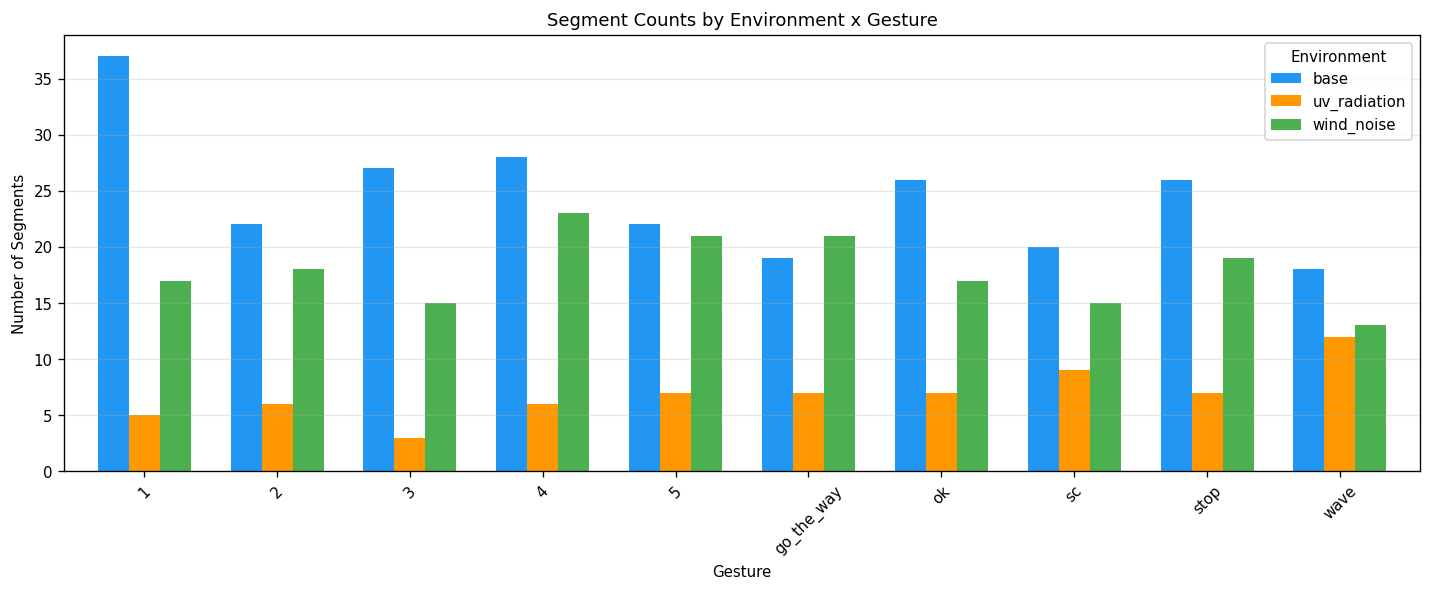

In [12]:
# Bar chart
plot_cols = [c for c in counts.columns if c != 'total']
ax = counts[plot_cols].plot(kind='bar', figsize=(12, 5), width=0.7,
                            color=['#2196F3', '#FF9800', '#4CAF50'])
ax.set_ylabel('Number of Segments')
ax.set_xlabel('Gesture')
ax.set_title('Segment Counts by Environment x Gesture')
ax.legend(title='Environment')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

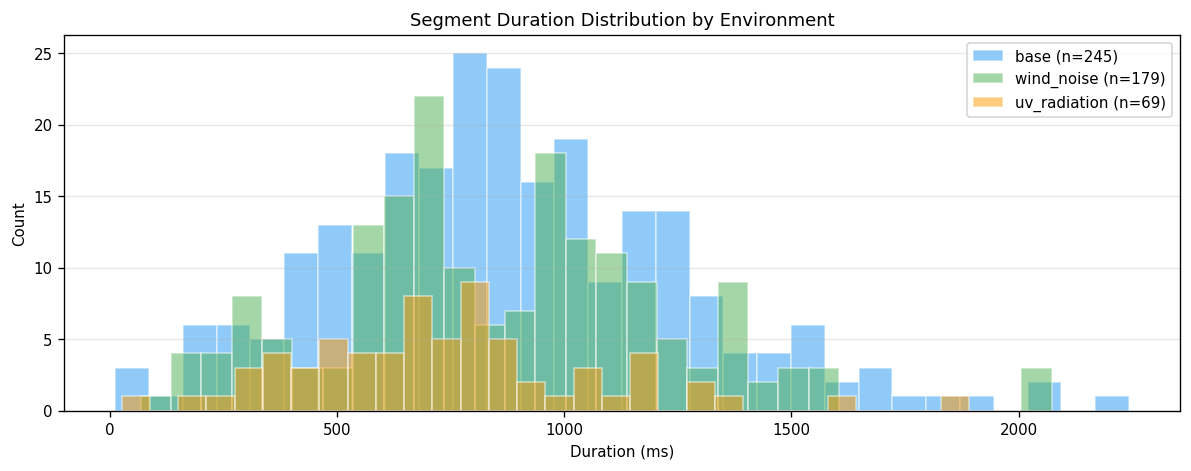

Duration statistics (ms):
              count   mean    std   min    25%    50%     75%     max
env                                                                  
base          245.0  881.0  387.6  11.0  631.0  848.0  1125.0  2243.0
uv_radiation   69.0  743.4  332.3  25.0  518.0  719.0   876.0  1891.0
wind_noise    179.0  860.9  374.8  67.0  620.0  813.0  1094.0  2073.0


In [13]:
# Duration distribution
fig, ax = plt.subplots(figsize=(10, 4))
for env, color in zip(['base', 'wind_noise', 'uv_radiation'], ['#2196F3', '#4CAF50', '#FF9800']):
    subset = all_feat[all_feat['env'] == env]['duration_ms']
    ax.hist(subset, bins=30, alpha=0.5, label=f'{env} (n={len(subset)})', color=color, edgecolor='white')

ax.set_xlabel('Duration (ms)')
ax.set_ylabel('Count')
ax.set_title('Segment Duration Distribution by Environment')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Duration statistics (ms):')
print(all_feat.groupby('env')['duration_ms'].describe().round(1))

### 如何读这些图

**柱状图**：
- 每个手势有 3 根柱子，分别对应 3 种环境
- 理想情况下各手势样本数量应大致均衡
- base 环境样本最多（来自两批次合并），uv_radiation 最少（仅 5 次/文件）

**直方图**：
- 展示各环境下切出片段的时长分布
- 片段时长通常在 500-2500ms 之间，不同手势的持续时间可能不同
- 过短（<200ms）或过长（>2800ms）的片段已被算法过滤

这些统计结果将用于决定 train/test 划分策略。

---
## 总结

本 Notebook 展示了完整的预处理流程：

1. **原始信号**：3 通道 TENG 电压信号，每文件包含多次重复手势
2. **动作切分**：滑动 RMS + 跨通道联合检测 + 纯净度自检，自动识别并切出干净的单次动作
3. **信号清洗**：去直流 → 带通(20-450Hz) → 陷波(50Hz) → 谱减法 → 边界裁切
4. **特征提取**：9D 向量 [MAV x3, WL x3, Ratio x3]，捕获力度、复杂度、空间分布
5. **统计分析**：493 个有效样本，10 类手势，3 种环境

下一步：确定 train/test 划分策略，训练 MLP 分类模型。